In [1]:
import pandas as pd

df = pd.read_csv("umap_all_methods_results_with_fno_metrics.csv")

In [2]:
def update_dict(row, dict_col, columns):
    """Update dictionary with column names as keys and cell values as values"""
    # Handle different types in the dict column
    if pd.isna(row[dict_col]):
        current_dict = {}
    elif isinstance(row[dict_col], dict):
        current_dict = row[dict_col].copy()
    elif isinstance(row[dict_col], str):
        try:
            # Try to convert string to dict (if it's JSON-like)
            current_dict = eval(row[dict_col]) if row[dict_col].startswith('{') else {}
        except:
            current_dict = {}
    else:
        current_dict = {}
    
    # Add new key-value pairs
    for col in columns:
        current_dict[col] = row[col]
    
    return current_dict

# Update the dictionary column
df['grf_config'] = df.apply(
    lambda row: update_dict(row, 'grf_config', ["data_type"]), 
    axis=1
)

In [3]:
import pandas as pd
import json
from ast import literal_eval

# 1. First convert the nested dict to a hashable format
def make_hashable(d):
    if isinstance(d, dict):
        return tuple(sorted((k, make_hashable(v)) for k, v in d.items()))
    elif isinstance(d, list):
        return tuple(make_hashable(x) for x in d)
    return d

# 2. Create a grouping key column
df['group_key'] = df['grf_config'].apply(
    lambda x: make_hashable(x) if pd.notna(x) and isinstance(x, dict) else x
)

# 3. Now group by this key and calculate mean
mean_values = df.groupby('group_key')['fno_rmse'].mean().reset_index()

# Optional: Convert back to readable format
mean_values['grf_config'] = mean_values['group_key'].apply(
    lambda x: dict(x) if isinstance(x, tuple) else x
)

In [4]:
mean_values.sort_values("fno_rmse")

,group_key,fno_rmse,grf_config
122,"((data_type, generalizability), (grf_type, GRF...",0.056967,"{'data_type': 'generalizability', 'grf_type': ..."
123,"((data_type, generalizability), (grf_type, GRF...",0.067328,"{'data_type': 'generalizability', 'grf_type': ..."
146,"((data_type, generalizability), (grf_type, GRF...",0.070636,"{'data_type': 'generalizability', 'grf_type': ..."
158,"((data_type, generalizability), (grf_type, GRF...",0.070801,"{'data_type': 'generalizability', 'grf_type': ..."
170,"((data_type, generalizability), (grf_type, GRF...",0.072674,"{'data_type': 'generalizability', 'grf_type': ..."
...,...,...,...
738,"((data_type, generalizability), (grf_type, Log...",1.622512,"{'data_type': 'generalizability', 'grf_type': ..."
714,"((data_type, generalizability), (grf_type, Log...",1.623987,"{'data_type': 'generalizability', 'grf_type': ..."
618,"((data_type, generalizability), (grf_type, Log...",1.626001,"{'data_type': 'generalizability', 'grf_type': ..."
924,"((data_type, generalizability), (grf_type, Log...",1.628565,"{'data_type': 'generalizability', 'grf_type': ..."


/tmp/ipykernel_2669466/3325908637.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  ax = sns.barplot(data=mean_values,
/tmp/ipykernel_2669466/3325908637.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=mean_values,


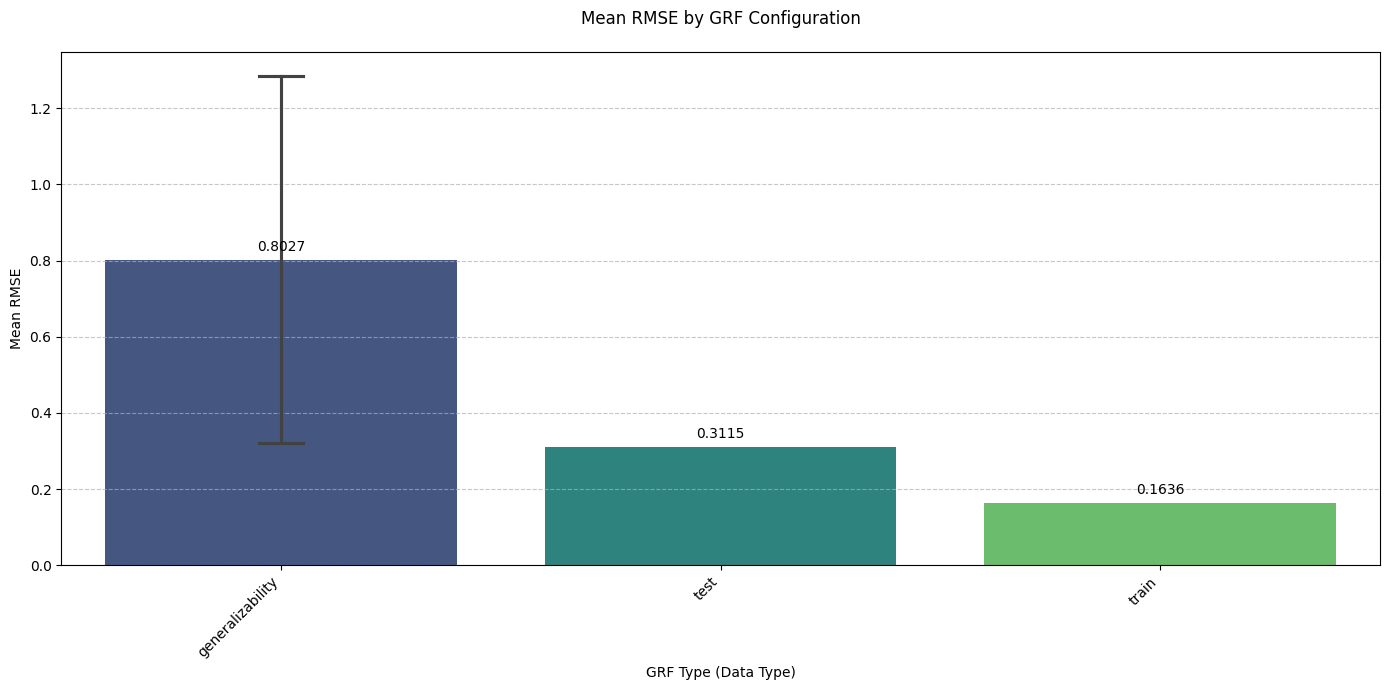

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

mean_values['data_type'] = mean_values['grf_config'].apply(lambda x: x['data_type'])

# Create a combined label for better readability
mean_values['group_label'] = mean_values['data_type']

plt.figure(figsize=(14, 7))
ax = sns.barplot(data=mean_values, 
                 x='group_label', 
                 y='fno_rmse', 
                 ci='sd', 
                 capsize=0.1,
                 palette='viridis')

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')

plt.xticks(rotation=45, ha='right')
plt.title('Mean RMSE by GRF Configuration', pad=20)
plt.ylabel('Mean RMSE')
plt.xlabel('GRF Type (Data Type)')
ax.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2669466/3075226744.py:39: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  ax = sns.barplot(data=mean_values_sorted,


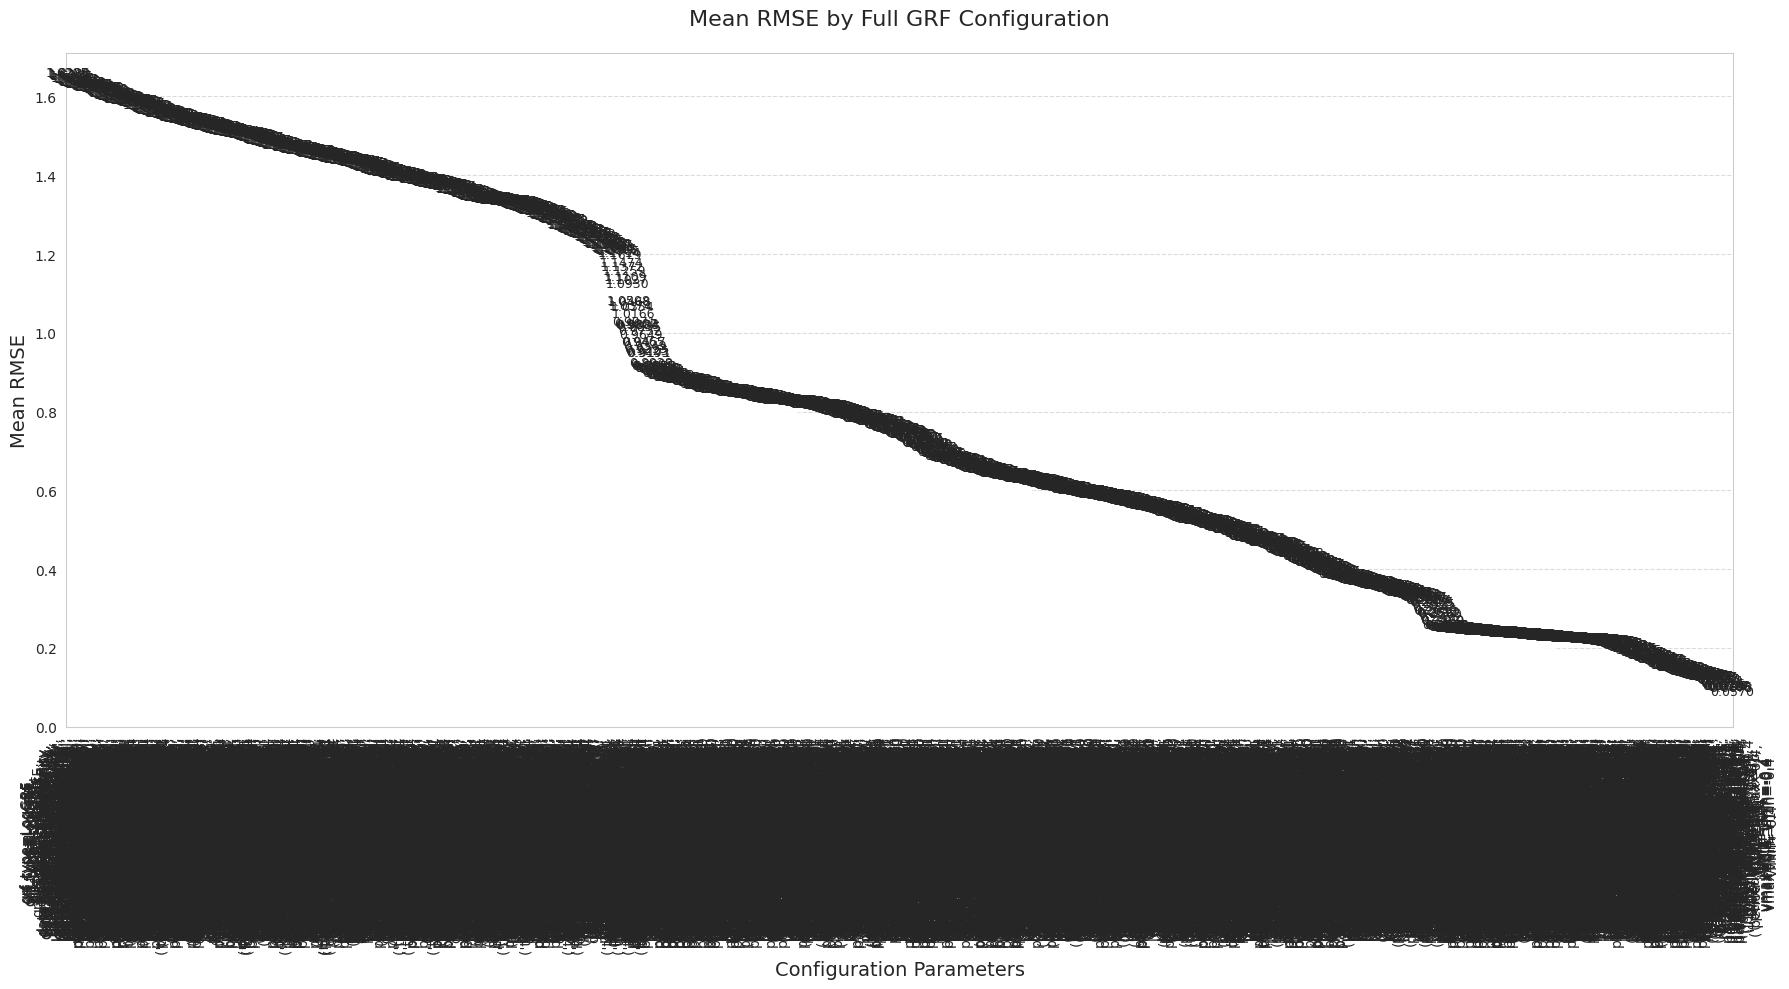

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from textwrap import wrap

# 1. Extract all keys from the nested dictionary
all_keys = set()
for config in mean_values['grf_config']:
    if isinstance(config, dict):
        all_keys.update(config.keys())

# 2. Create columns for each configuration parameter
for key in all_keys:
    mean_values[key] = mean_values['grf_config'].apply(
        lambda x: x.get(key) if isinstance(x, dict) else None
    )

# 3. Create a combined label column with all parameters
def create_full_label(row):
    if isinstance(row['grf_config'], dict):
        parts = []
        for k, v in row['grf_config'].items():
            if k in ['grf_type', 'data_type']:  # Put important ones first
                parts.insert(0, f"{k}={v}")
            else:
                parts.append(f"{k}={v}")
        return "\n".join(wrap(", ".join(parts), width=30))
    return str(row['grf_config'])

mean_values['full_config'] = mean_values.apply(create_full_label, axis=1)

# 4. Sort by RMSE for better visualization
mean_values_sorted = mean_values.sort_values('fno_rmse', ascending=False)

# 5. Create the visualization
plt.figure(figsize=(18, 10))
sns.set_style("whitegrid")
sns.set_palette("husl")

ax = sns.barplot(data=mean_values_sorted,
                x='full_config',
                y='fno_rmse',
                ci='sd',
                capsize=0.1)

# Customize the plot
plt.title('Mean RMSE by Full GRF Configuration', pad=20, fontsize=16)
plt.ylabel('Mean RMSE', fontsize=14)
plt.xlabel('Configuration Parameters', fontsize=14)
plt.xticks(rotation=90, ha='center', fontsize=10)

# Add value labels
for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}", 
               (p.get_x() + p.get_width() / 2., p.get_height()),
               ha='center', va='center', 
               xytext=(0, 9), 
               textcoords='offset points',
               fontsize=9)

# Add horizontal grid lines
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Adjust layout
plt.tight_layout()
plt.show()

/tmp/ipykernel_2694702/3486051503.py:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(unique_pairs))


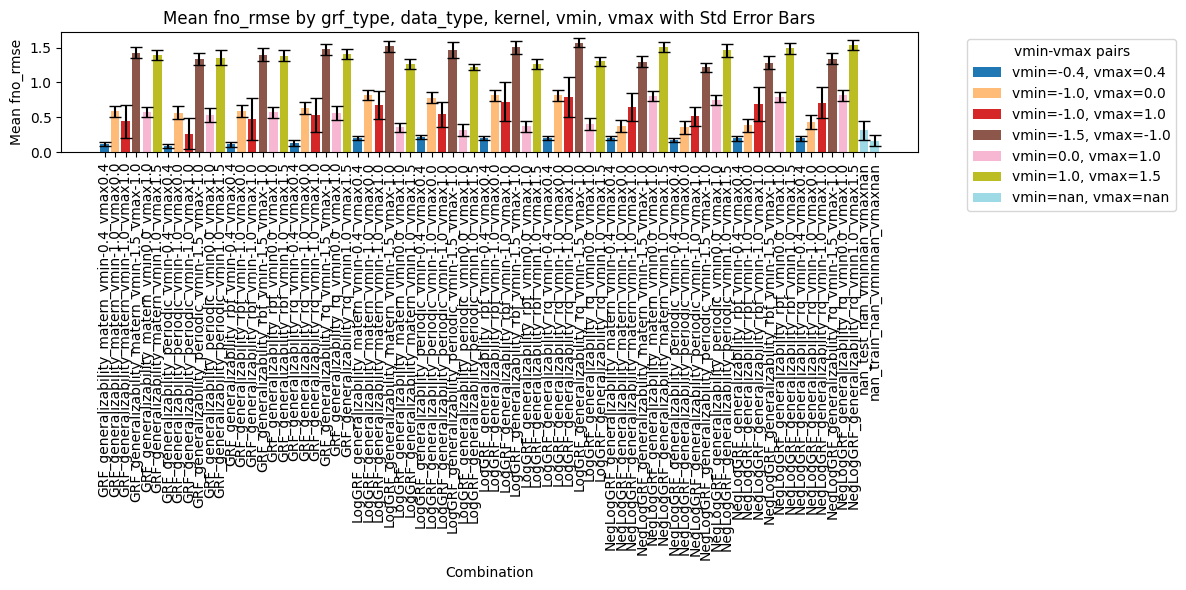

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from matplotlib.patches import Patch

# 展开 grf_config
df_config = pd.json_normalize(df['grf_config'])

# 避免列名冲突
for col in df_config.columns:
    if col in df.columns:
        df_config.rename(columns={col: col + '_config'}, inplace=True)

# 合并
df_combined = pd.concat([df.drop(columns=['grf_config']), df_config], axis=1)

# 分组列
group_cols = ['grf_type', 'data_type_config', 'kernel', 'vmin', 'vmax']

# 确保这些列都是字符串
for col in group_cols:
    df_combined[col] = df_combined[col].apply(lambda x: str(x) if not pd.api.types.is_scalar(x) else x)
    df_combined[col] = df_combined[col].astype(str)

# 分组求均值、标准差
grouped = df_combined.groupby(group_cols)['fno_rmse']
mean_values = grouped.mean().reset_index()
std_values = grouped.std().reset_index()

# 合并均值和标准差
mean_values['std'] = std_values['fno_rmse']

# 6. 生成标签
mean_values['combo'] = mean_values.apply(
    lambda row: f"{row['grf_type']}_{row['data_type_config']}_{row['kernel']}_vmin{row['vmin']}_vmax{row['vmax']}",
    axis=1
)

# 额外：生成vmin-vmax组合列，方便映射颜色
mean_values['vmin_vmax'] = mean_values.apply(lambda row: (row['vmin'], row['vmax']), axis=1)

# 给不同vmin_vmax组合编号
unique_pairs = mean_values['vmin_vmax'].unique()
pair_to_int = {pair: i for i, pair in enumerate(unique_pairs)}

# 颜色映射，使用一个 colormap，比如 tab20 或 viridis
cmap = plt.cm.get_cmap('tab20', len(unique_pairs))

# 根据pair编号映射颜色
colors = [cmap(pair_to_int[pair]) for pair in mean_values['vmin_vmax']]

# 7. 画图，带标准差误差条
plt.figure(figsize=(12, 6))
bars = plt.bar(mean_values['combo'], mean_values['fno_rmse'], color=colors, yerr=mean_values['std'], capsize=4)
plt.xticks(rotation=90)
plt.xlabel('Combination')
plt.ylabel('Mean fno_rmse')
plt.title('Mean fno_rmse by grf_type, data_type, kernel, vmin, vmax with Std Error Bars')

# 添加图例
legend_elements = [Patch(facecolor=cmap(pair_to_int[pair]), label=f'vmin={pair[0]}, vmax={pair[1]}') 
                   for pair in unique_pairs]
plt.legend(handles=legend_elements, title='vmin-vmax pairs', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


/tmp/ipykernel_2694702/2206615389.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(unique_combos))
/tmp/ipykernel_2694702/2206615389.py:84: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


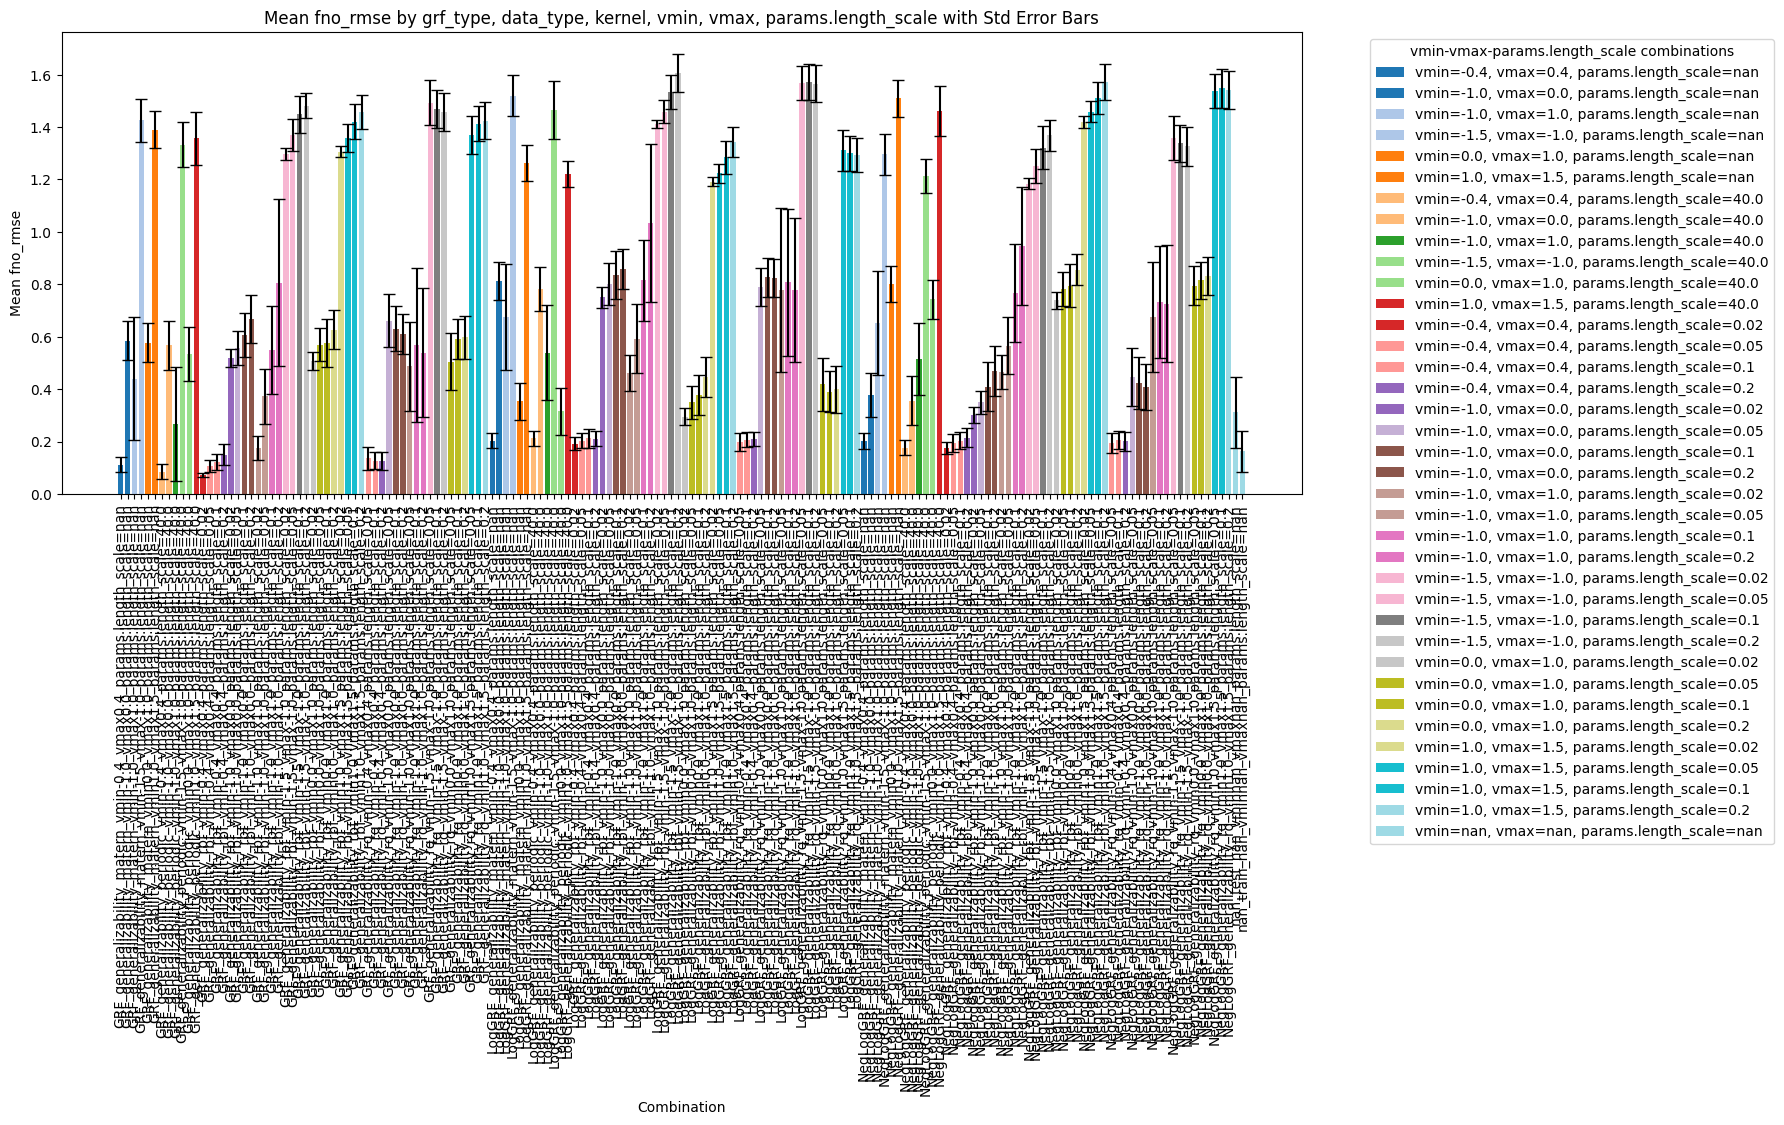

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# === Step 1. 展开 grf_config ===
df_config = pd.json_normalize(df['grf_config'])

# 如果 grf_config 里有 params，则展开
if 'params' in df_config.columns:
    df_params = pd.json_normalize(df_config['params'])
    df_params.columns = [f'params_{col}' for col in df_params.columns]
    df_config = pd.concat([df_config.drop(columns=['params']), df_params], axis=1)

# 避免列名冲突
for col in df_config.columns:
    if col in df.columns:
        df_config.rename(columns={col: col + '_config'}, inplace=True)

# 合并原始 df 和 df_config
df_combined = pd.concat([df.drop(columns=['grf_config']), df_config], axis=1)

# === Step 2. 定义分组列 ===
group_cols = ['grf_type', 'data_type_config', 'kernel', 'vmin', 'vmax']

# 把 params_xxx 列动态加入分组列
param_cols = [col for col in df_combined.columns if col.startswith('params.') and col.endswith('length_scale')]
group_cols += param_cols

# 确保这些列都是字符串
for col in group_cols:
    df_combined[col] = df_combined[col].apply(lambda x: str(x) if not pd.api.types.is_scalar(x) else x)
    df_combined[col] = df_combined[col].astype(str)

# === Step 3. 分组计算均值 & 标准差 ===
grouped = df_combined.groupby(group_cols)['fno_rmse']
mean_values = grouped.mean().reset_index()
std_values = grouped.std().reset_index()
mean_values['std'] = std_values['fno_rmse']

# 生成组合标签用于 x 轴
mean_values['combo'] = mean_values.apply(
    lambda row: f"{row['grf_type']}_{row['data_type_config']}_{row['kernel']}_"
                f"vmin{row['vmin']}_vmax{row['vmax']}_{params_for_color}={row[params_for_color]}",
    axis=1
)

# === Step 4. 定义颜色映射键 ===
# 使用第一个 params_xxx 列作为参数维度
params_for_color = param_cols[0] if param_cols else None
if params_for_color is None:
    raise ValueError("No params column found for coloring!")

# 创建颜色分组键 (vmin, vmax, params_xxx)
mean_values['vmin_vmax_param'] = mean_values.apply(
    lambda row: (row['vmin'], row['vmax'], row[params_for_color]), axis=1
)

# 映射颜色
unique_combos = mean_values['vmin_vmax_param'].unique()
combo_to_int = {combo: i for i, combo in enumerate(unique_combos)}
cmap = plt.cm.get_cmap('tab20', len(unique_combos))
colors = [cmap(combo_to_int[combo]) for combo in mean_values['vmin_vmax_param']]

# === Step 5. 绘图 ===
plt.figure(figsize=(16, 6))
plt.bar(mean_values['combo'], mean_values['fno_rmse'], 
        color=colors, yerr=mean_values['std'], capsize=4)

plt.xticks(rotation=90)
plt.xlabel('Combination')
plt.ylabel('Mean fno_rmse')
plt.title(f'Mean fno_rmse by grf_type, data_type, kernel, vmin, vmax, {params_for_color} with Std Error Bars')

# 图例
legend_elements = [
    Patch(facecolor=cmap(combo_to_int[combo]), 
          label=f'vmin={combo[0]}, vmax={combo[1]}, {params_for_color}={combo[2]}')
    for combo in unique_combos
]
plt.legend(handles=legend_elements, title=f'vmin-vmax-{params_for_color} combinations',
           bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


/tmp/ipykernel_2694702/1972082721.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(unique_combos))
/tmp/ipykernel_2694702/1972082721.py:84: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


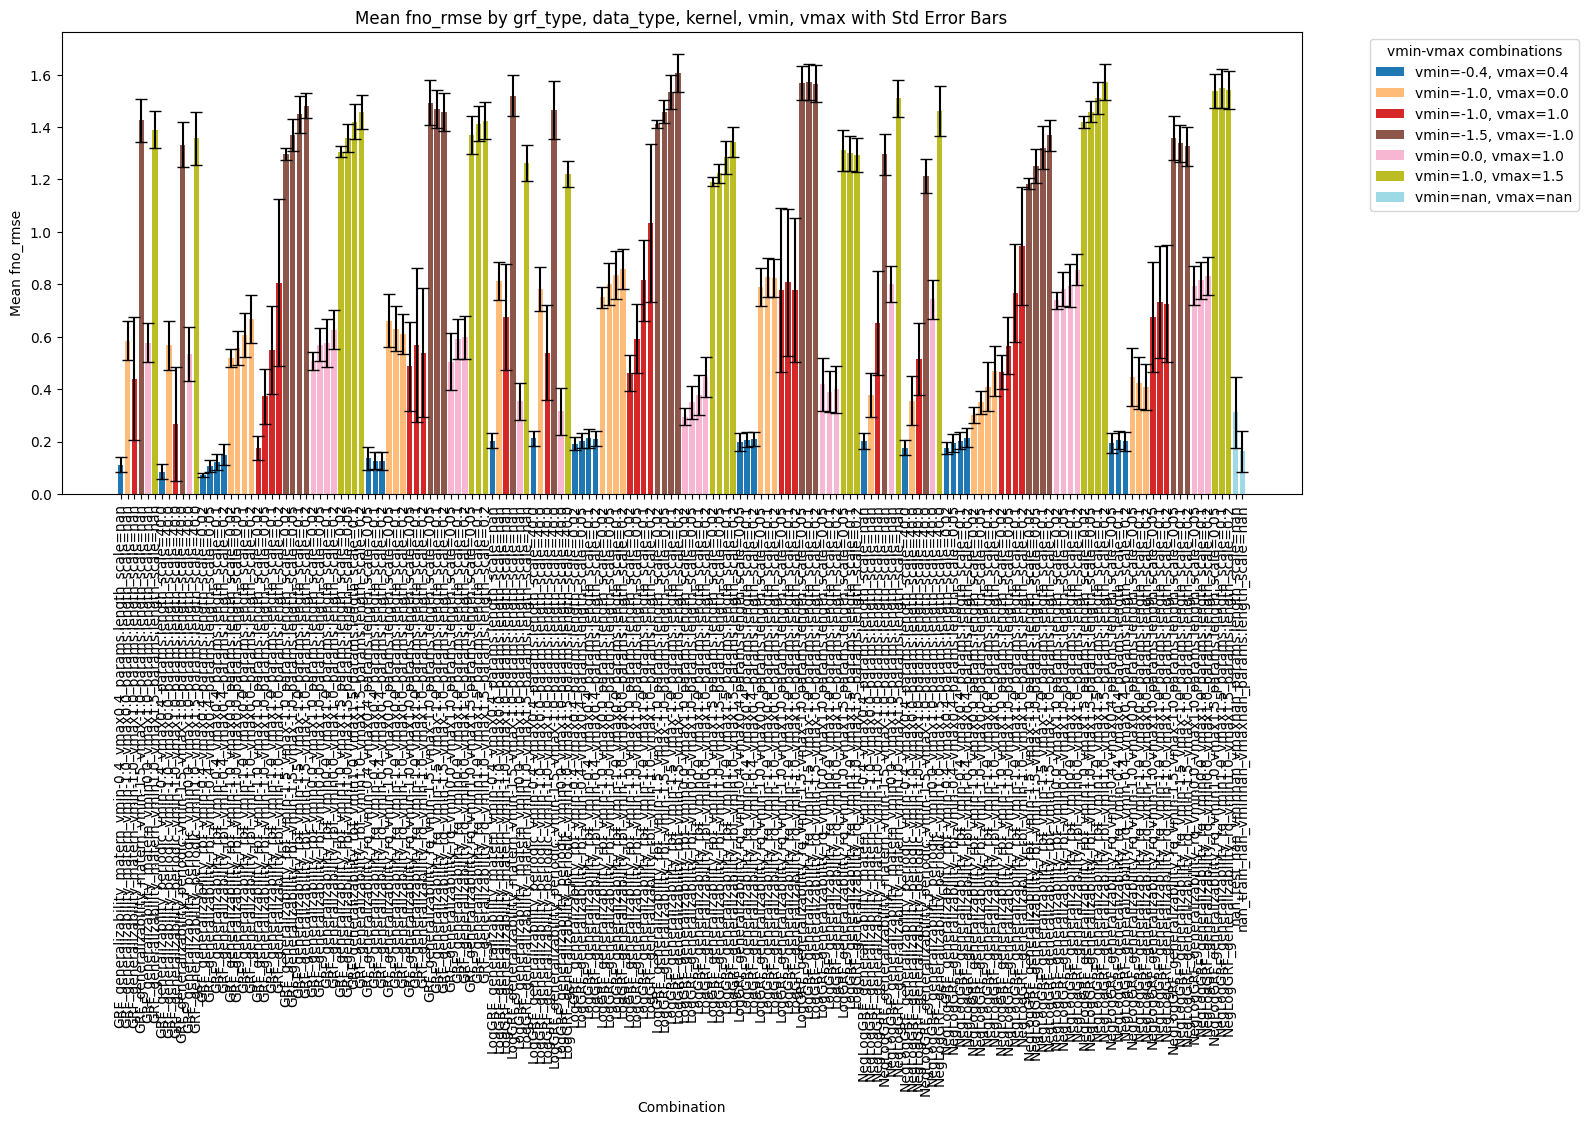

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# === Step 1. 展开 grf_config ===
df_config = pd.json_normalize(df['grf_config'])

# 如果 grf_config 里有 params，则展开
if 'params' in df_config.columns:
    df_params = pd.json_normalize(df_config['params'])
    df_params.columns = [f'params_{col}' for col in df_params.columns]
    df_config = pd.concat([df_config.drop(columns=['params']), df_params], axis=1)

# 避免列名冲突
for col in df_config.columns:
    if col in df.columns:
        df_config.rename(columns={col: col + '_config'}, inplace=True)

# 合并原始 df 和 df_config
df_combined = pd.concat([df.drop(columns=['grf_config']), df_config], axis=1)

# === Step 2. 定义分组列 ===
group_cols = ['grf_type', 'data_type_config', 'kernel', 'vmin', 'vmax']

# 把 params_xxx 列动态加入分组列
param_cols = [col for col in df_combined.columns if col.startswith('params.') and col.endswith('length_scale')]
group_cols += param_cols

# 确保这些列都是字符串
for col in group_cols:
    df_combined[col] = df_combined[col].apply(lambda x: str(x) if not pd.api.types.is_scalar(x) else x)
    df_combined[col] = df_combined[col].astype(str)

# === Step 3. 分组计算均值 & 标准差 ===
grouped = df_combined.groupby(group_cols)['fno_rmse']
mean_values = grouped.mean().reset_index()
std_values = grouped.std().reset_index()
mean_values['std'] = std_values['fno_rmse']

# 生成组合标签用于 x 轴
mean_values['combo'] = mean_values.apply(
    lambda row: f"{row['grf_type']}_{row['data_type_config']}_{row['kernel']}_"
                f"vmin{row['vmin']}_vmax{row['vmax']}_{params_for_color}={row[params_for_color]}",
    axis=1
)

# === Step 4. 定义颜色映射键 ===
# 使用第一个 params_xxx 列作为参数维度
params_for_color = param_cols[0] if param_cols else None
if params_for_color is None:
    raise ValueError("No params column found for coloring!")

# 创建颜色分组键 (vmin, vmax)
mean_values['vmin_vmax'] = mean_values.apply(
    lambda row: (row['vmin'], row['vmax']), axis=1
)

# 映射颜色
unique_combos = mean_values['vmin_vmax'].unique()
combo_to_int = {combo: i for i, combo in enumerate(unique_combos)}
cmap = plt.cm.get_cmap('tab20', len(unique_combos))
colors = [cmap(combo_to_int[combo]) for combo in mean_values['vmin_vmax']]

# 绘图
plt.figure(figsize=(16, 6))
plt.bar(mean_values['combo'], mean_values['fno_rmse'], 
        color=colors, yerr=mean_values['std'], capsize=4)

plt.xticks(rotation=90)
plt.xlabel('Combination')
plt.ylabel('Mean fno_rmse')
plt.title(f'Mean fno_rmse by grf_type, data_type, kernel, vmin, vmax with Std Error Bars')

# 图例
legend_elements = [
    Patch(facecolor=cmap(combo_to_int[combo]), 
          label=f'vmin={combo[0]}, vmax={combo[1]}')
    for combo in unique_combos
]
plt.legend(handles=legend_elements, title='vmin-vmax combinations',
           bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2694702/488043455.py:59: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(unique_params))
/tmp/ipykernel_2694702/488043455.py:81: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


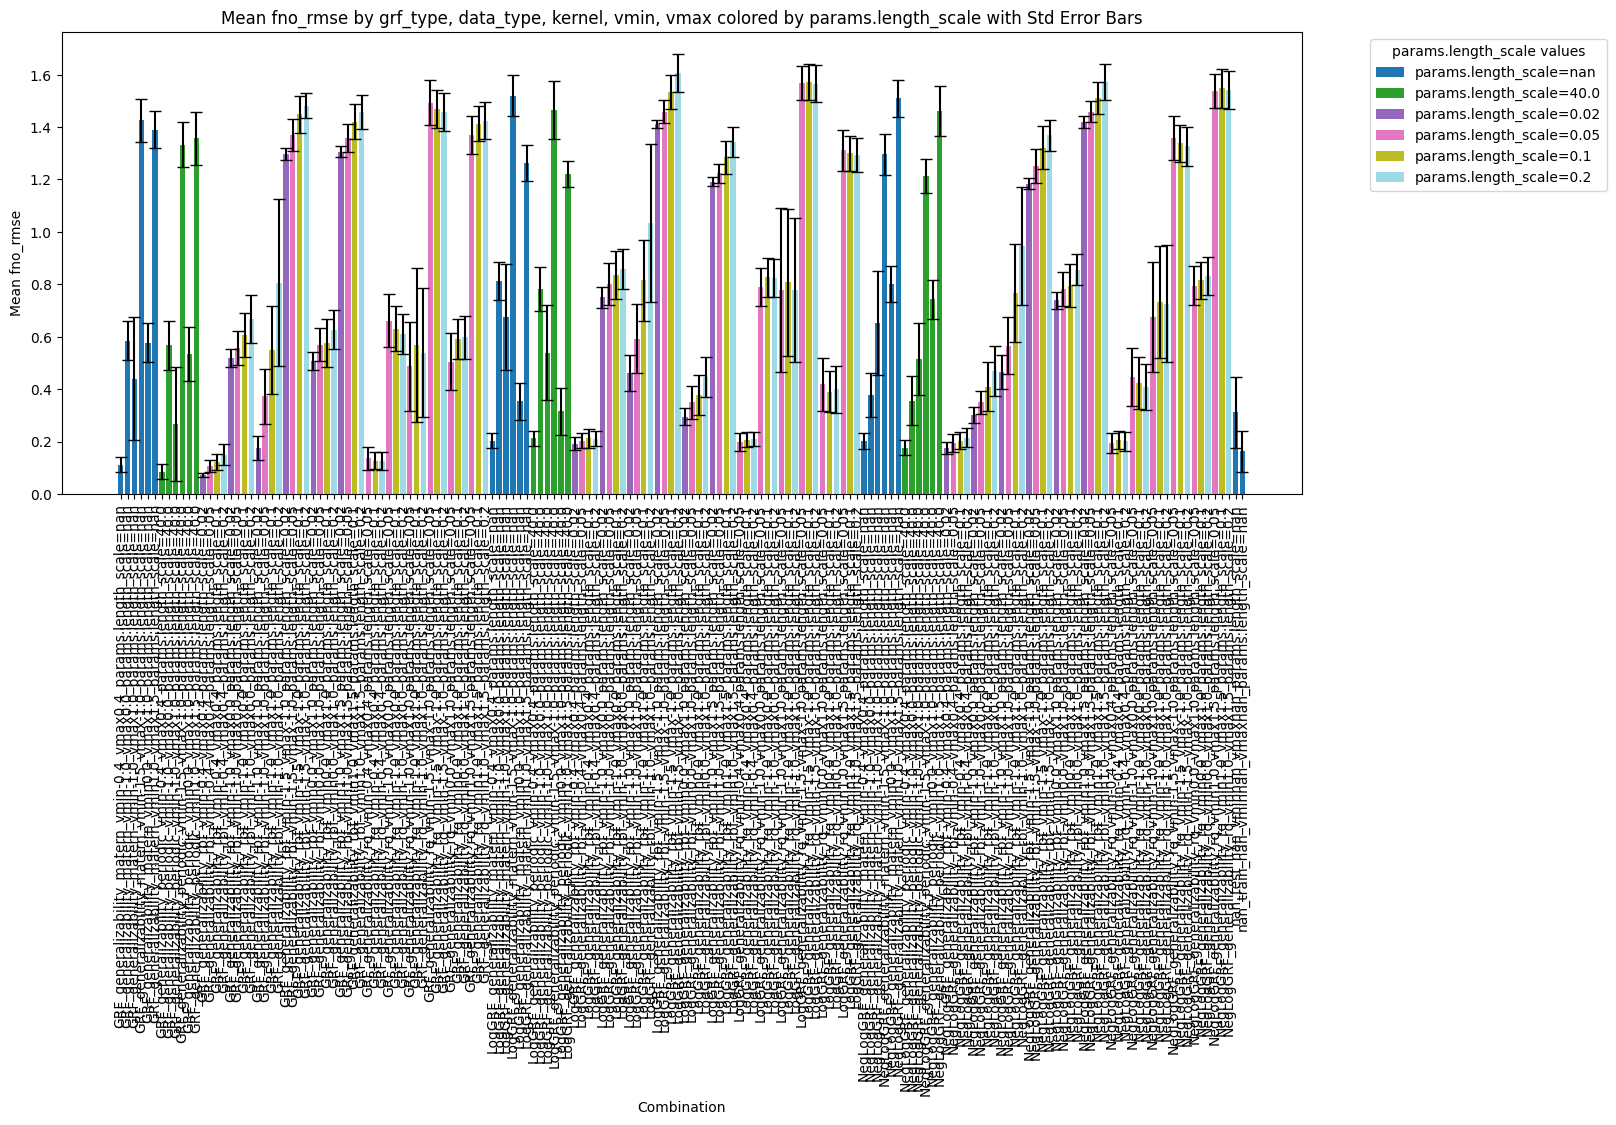

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# === Step 1. 展开 grf_config ===
df_config = pd.json_normalize(df['grf_config'])

# 如果 grf_config 里有 params，则展开
if 'params' in df_config.columns:
    df_params = pd.json_normalize(df_config['params'])
    df_params.columns = [f'params_{col}' for col in df_params.columns]
    df_config = pd.concat([df_config.drop(columns=['params']), df_params], axis=1)

# 避免列名冲突
for col in df_config.columns:
    if col in df.columns:
        df_config.rename(columns={col: col + '_config'}, inplace=True)

# 合并原始 df 和 df_config
df_combined = pd.concat([df.drop(columns=['grf_config']), df_config], axis=1)

# === Step 2. 定义分组列 ===
group_cols = ['grf_type', 'data_type_config', 'kernel', 'vmin', 'vmax']

# 把 params_xxx 列动态加入分组列
param_cols = [col for col in df_combined.columns if col.startswith('params.') and col.endswith('length_scale')]
group_cols += param_cols

# 确保这些列都是字符串
for col in group_cols:
    df_combined[col] = df_combined[col].apply(lambda x: str(x) if not pd.api.types.is_scalar(x) else x)
    df_combined[col] = df_combined[col].astype(str)

# === Step 3. 分组计算均值 & 标准差 ===
grouped = df_combined.groupby(group_cols)['fno_rmse']
mean_values = grouped.mean().reset_index()
std_values = grouped.std().reset_index()
mean_values['std'] = std_values['fno_rmse']

# === Step 4. 定义颜色映射键 ===
# 选择第一个 params_xxx 列作为颜色维度
params_for_color = param_cols[0] if param_cols else None
if params_for_color is None:
    raise ValueError("No params column found for coloring!")

# 生成组合标签用于 x 轴
mean_values['combo'] = mean_values.apply(
    lambda row: f"{row['grf_type']}_{row['data_type_config']}_{row['kernel']}_"
                f"vmin{row['vmin']}_vmax{row['vmax']}_{params_for_color}={row[params_for_color]}",
    axis=1
)

# 颜色分组只用 params
mean_values['param_value'] = mean_values[params_for_color]

unique_params = mean_values['param_value'].unique()
param_to_int = {val: i for i, val in enumerate(unique_params)}
cmap = plt.cm.get_cmap('tab20', len(unique_params))
colors = [cmap(param_to_int[val]) for val in mean_values['param_value']]

# === Step 5. 绘图 ===
plt.figure(figsize=(16, 6))
plt.bar(mean_values['combo'], mean_values['fno_rmse'], 
        color=colors, yerr=mean_values['std'], capsize=4)

plt.xticks(rotation=90)
plt.xlabel('Combination')
plt.ylabel('Mean fno_rmse')
plt.title(f'Mean fno_rmse by grf_type, data_type, kernel, vmin, vmax colored by {params_for_color} with Std Error Bars')

# 图例
legend_elements = [
    Patch(facecolor=cmap(param_to_int[val]), 
          label=f'{params_for_color}={val}')
    for val in unique_params
]
plt.legend(handles=legend_elements, title=f'{params_for_color} values',
           bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2694702/728201743.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(unique_combos))


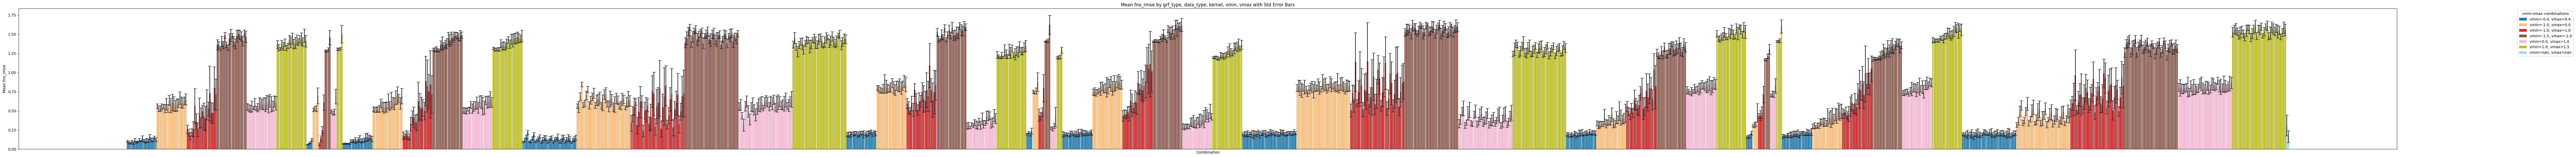

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# === Step 1. 展开 grf_config ===
df_config = pd.json_normalize(df['grf_config'])

# 如果 grf_config 里有 params，则展开
if 'params' in df_config.columns:
    df_params = pd.json_normalize(df_config['params'])
    df_params.columns = [f'params_{col}' for col in df_params.columns]
    df_config = pd.concat([df_config.drop(columns=['params']), df_params], axis=1)

# 避免列名冲突
for col in df_config.columns:
    if col in df.columns:
        df_config.rename(columns={col: col + '_config'}, inplace=True)

# 合并原始 df 和 df_config
df_combined = pd.concat([df.drop(columns=['grf_config']), df_config], axis=1)

# === Step 2. 定义分组列 ===
group_cols = ['grf_type', 'data_type_config', 'kernel', 'vmin', 'vmax']

# 把 params_xxx 列动态加入分组列
param_cols = [col for col in df_combined.columns if col.startswith('params.')]
group_cols += param_cols

# 确保这些列都是字符串
for col in group_cols:
    df_combined[col] = df_combined[col].apply(lambda x: str(x) if not pd.api.types.is_scalar(x) else x)
    df_combined[col] = df_combined[col].astype(str)

# === Step 3. 分组计算均值 & 标准差 ===
grouped = df_combined.groupby(group_cols)['fno_rmse']
mean_values = grouped.mean().reset_index()
std_values = grouped.std().reset_index()
mean_values['std'] = std_values['fno_rmse']

# 生成唯一组合标签
mean_values['combo'] = mean_values.apply(
    lambda row: "_".join([f"{col}={row[col]}" for col in group_cols]),
    axis=1
)

# 创建颜色分组键 (vmin, vmax)
mean_values['vmin_vmax'] = mean_values.apply(
    lambda row: (row['vmin'], row['vmax']), axis=1
)

# 映射颜色
unique_combos = mean_values['vmin_vmax'].unique()
combo_to_int = {combo: i for i, combo in enumerate(unique_combos)}
cmap = plt.cm.get_cmap('tab20', len(unique_combos))
colors = [cmap(combo_to_int[combo]) for combo in mean_values['vmin_vmax']]

# 绘图
plt.figure(figsize=(96, 6))
plt.bar(mean_values['combo'], mean_values['fno_rmse'], 
        color=colors, yerr=mean_values['std'], capsize=4)

plt.xticks([]) 
plt.xlabel('Combination')
plt.ylabel('Mean fno_rmse')
plt.title(f'Mean fno_rmse by grf_type, data_type, kernel, vmin, vmax with Std Error Bars')

# 图例
legend_elements = [
    Patch(facecolor=cmap(combo_to_int[combo]), 
          label=f'vmin={combo[0]}, vmax={combo[1]}')
    for combo in unique_combos
]
plt.legend(handles=legend_elements, title='vmin-vmax combinations',
           bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()